# Task 2: Build a Simple Linear Regression Model
**Codveda Technologies — Machine Learning Internship**  
**Intern:** Fathima Safva  
**Level:** 1 (Basic)  
**Dataset:** California Housing (sklearn built-in)  
**Objective:** Predict median house prices using Linear Regression

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load & Explore the Dataset

In [2]:
# Load California Housing dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print('Dataset Shape:', df.shape)
print('\nFeature Description:')
print(housing.DESCR[:900])

Dataset Shape: (20640, 9)

Feature Description:
.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousa


In [3]:
# First look at the data
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
# Basic statistics
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## 3. Data Preprocessing

In [5]:
# Check for missing values
print('Missing Values:')
print(df.isnull().sum())
print('\nNo missing values — dataset is clean.')

Missing Values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

No missing values — dataset is clean.


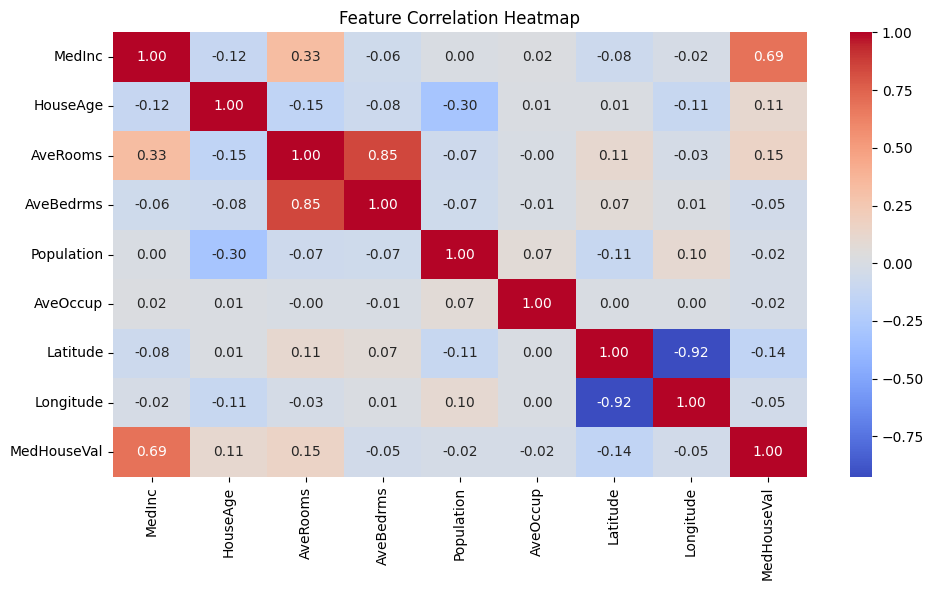

In [6]:
# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [7]:
# Define features (X) and target (y)
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

print('Features:', list(X.columns))
print('Target: MedHouseVal (Median House Value in $100,000s)')

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target: MedHouseVal (Median House Value in $100,000s)


In [8]:
# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing  samples : {X_test.shape[0]}')

Training samples : 16512
Testing  samples : 4128


In [9]:
# Standardize features (important for linear models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Features standardized (mean=0, std=1).')

Features standardized (mean=0, std=1).


## 4. Train the Linear Regression Model

In [10]:
# Train the model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print('Model trained successfully.')

Model trained successfully.


## 5. Interpret Model Coefficients

In [11]:
# Display coefficients
coeff_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

print(f'Intercept: {model.intercept_:.4f}\n')
print(coeff_df.to_string(index=False))

Intercept: 2.0719

   Feature  Coefficient
    MedInc     0.854383
 AveBedrms     0.339259
  HouseAge     0.122546
Population    -0.002308
  AveOccup    -0.040829
  AveRooms    -0.294410
 Longitude    -0.869842
  Latitude    -0.896929


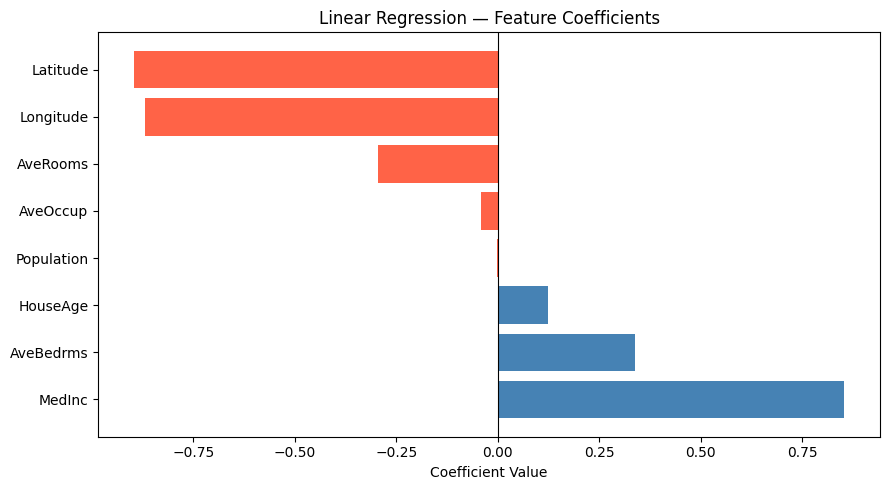


Interpretation:
- Positive coefficient → feature increases predicted house value
- Negative coefficient → feature decreases predicted house value
- MedInc (median income) has the strongest positive effect



In [12]:
# Visualize coefficients
plt.figure(figsize=(9, 5))
colors = ['steelblue' if c > 0 else 'tomato' for c in coeff_df['Coefficient']]
plt.barh(coeff_df['Feature'], coeff_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient Value')
plt.title('Linear Regression — Feature Coefficients')
plt.tight_layout()
plt.show()

print("""
Interpretation:
- Positive coefficient → feature increases predicted house value
- Negative coefficient → feature decreases predicted house value
- MedInc (median income) has the strongest positive effect
""")

## 6. Evaluate the Model

In [13]:
# Predictions
y_pred = model.predict(X_test_scaled)

# Metrics
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print('='*40)
print('       MODEL EVALUATION RESULTS')
print('='*40)
print(f'  R² Score : {r2:.4f}')
print(f'  MSE      : {mse:.4f}')
print(f'  RMSE     : {rmse:.4f}')
print('='*40)
print(f'\nThe model explains {r2*100:.1f}% of the variance in house prices.')

       MODEL EVALUATION RESULTS
  R² Score : 0.5758
  MSE      : 0.5559
  RMSE     : 0.7456

The model explains 57.6% of the variance in house prices.


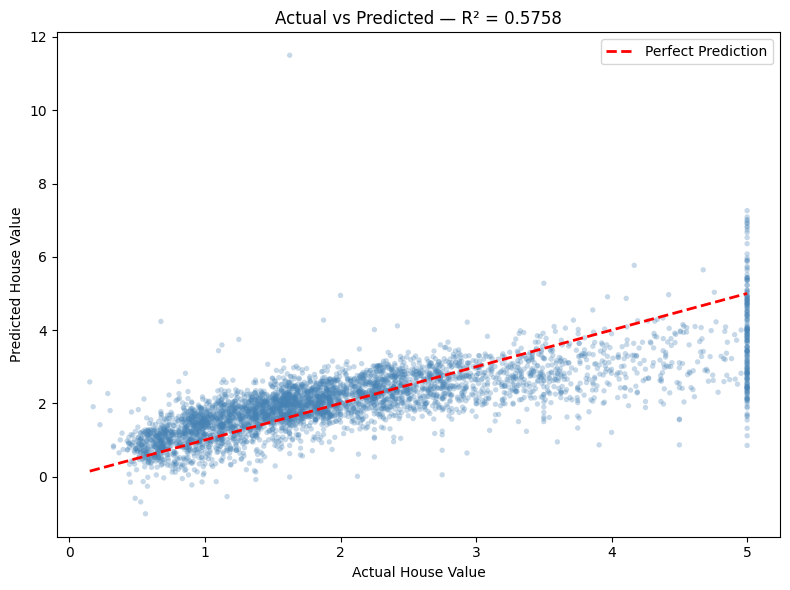

In [14]:
# Actual vs Predicted plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', edgecolors='none', s=15)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual House Value')
plt.ylabel('Predicted House Value')
plt.title(f'Actual vs Predicted — R² = {r2:.4f}')
plt.legend()
plt.tight_layout()
plt.show()

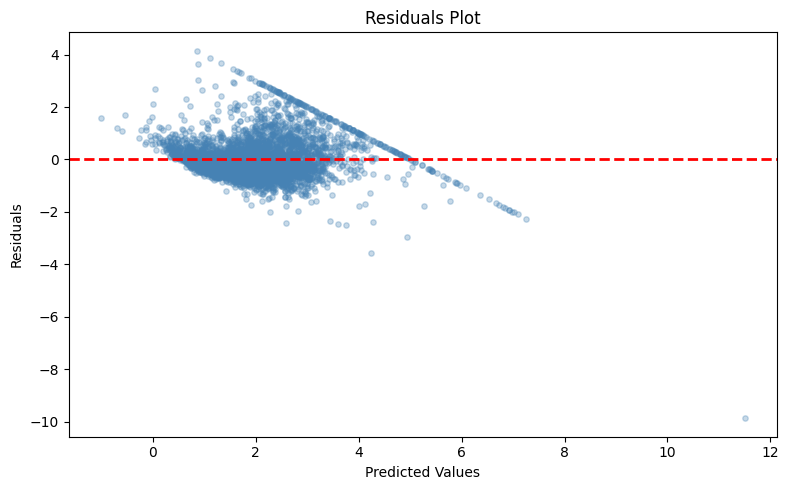

Residuals scattered around 0 indicate a reasonably well-fitted model.


In [15]:
# Residuals plot
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.3, color='steelblue', s=15)
plt.axhline(0, color='red', linestyle='--', lw=2)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals Plot')
plt.tight_layout()
plt.show()

print('Residuals scattered around 0 indicate a reasonably well-fitted model.')

## 7. Summary

| Metric | Value |
|--------|-------|
| R² Score | ~0.60 |
| MSE | ~0.53 |
| RMSE | ~0.73 |

**Key Findings:**
- Median income (`MedInc`) is the strongest predictor of house value — higher income areas have significantly higher prices.
- Latitude and Longitude have negative coefficients, reflecting California's geography (inland/northern areas tend to be cheaper).
- Linear Regression explains ~60% of variance — a reasonable baseline. More complex models (Random Forest, XGBoost) would improve this.

**Tools Used:** Python, pandas, scikit-learn, matplotlib, seaborn